In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor

from bptf import BPTF as BPTF
import bptf


<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

def compare_support(X, Y, thr=0.05):
    """
    Compare the binary ‘non-zero’ supports of two fitted tensors.
    Parameters
    ----------
    X, Y : torch.Tensor  (same shape)
        Reconstructions you want to compare.
    thr : float
        Entries ≤ thr are treated as structural zeros.
    Returns
    -------
    dict with TP, FP, FN counts + agreement metrics.
    """
    Sx = X > thr                       # support of your fit
    Sy = Y > thr                       # support of Aaron’s fit

    tp = (Sx &  Sy).sum().item()       # both predict non-zero
    fp = (Sx & ~Sy).sum().item()       # you only
    fn = (~Sx & Sy).sum().item()       # Aaron only
    union = (Sx | Sy).sum().item()

    precision = tp / (tp + fp) if tp + fp else 1.0
    recall    = tp / (tp + fn) if tp + fn else 1.0
    f1        = 2*precision*recall / (precision + recall) if precision+recall else 0.0
    jaccard   = tp / union if union else 1.0

    return dict(tp=tp, fp=fp, fn=fn,
                precision=precision, recall=recall,
                f1=f1, jaccard=jaccard)

# Generate data

In [3]:
use_existing_data = True

rn.seed(0)

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :12, :]
    data = sparse.COO(data)
    print(f'Percentage of cells that are non-zero: {data.data.shape[0] / np.prod(np.array(list(data.shape))) * 100: .3}%')
else:
    data = generate(shp=(200, 200, 20, 12, 3), K=10)[1]
    data = sparse.COO(data)

Percentage of cells that are non-zero:  0.713%


# Fit with BPTF

  8%|▊         | 41/500 [00:47<08:46,  1.15s/it]


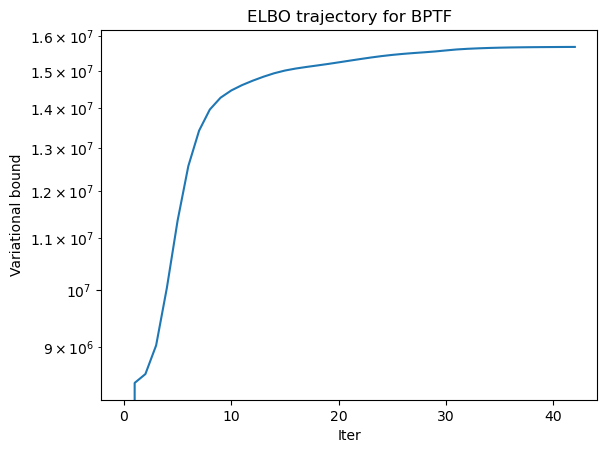

BPTF(data_shape=(280, 280, 20, 12, 3), n_components=10)

In [4]:
n_components = 10
max_iter = 500
device = 'cuda'
tol = 1e-4

mask = np.zeros(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 1

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 1
mask = sparse.COO(mask.astype(np.int64))

# BPTF_model_withmask = BPTF(data_shape=data.shape, n_components=n_components)
# BPTF_model_withmask.fit(data, mask = mask, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

BPTF_model_nomask = BPTF(data_shape=data.shape, n_components=n_components)
BPTF_model_nomask.fit(data, mask = None, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

# Fit with own BPTF_torch

In [5]:
from own_implementation import BPTF as BPTF_torch

Change is small enough, early break:   9%|▉         | 47/500 [00:24<03:52,  1.95it/s]                                                

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []


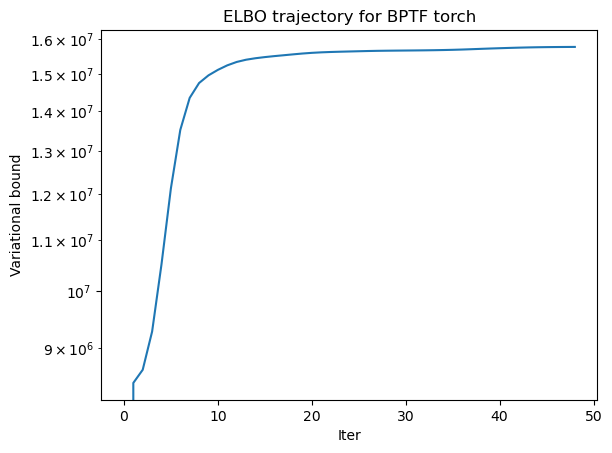

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=10)

In [6]:
mask = (1 - mask.todense()).astype(np.int64)
mask = torch.tensor(mask, dtype=torch.float64, device=device)

data = torch.tensor(data.todense(), dtype = torch.float64, device=device)
BPTF_model_torch_nomask = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model_torch_nomask.fit(data, mask = None, max_iter = max_iter, verbose=True, tol=tol)

# BPTF_model_torch_withmask = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
# BPTF_model_torch_withmask.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Check similarity

## No mask

Frobenius norm relative difference with only unmasked data: 0.1942487422552449


correlation index for geom mean 0.1695837207527861
correlation index for arithmetic mean 0.16957985492213343
Proportion of elements with difference greater than 0.05 = 0.05659722222222222
Fro norm of BPTF factors = 3.587576429836487
Fro norm of BPTF factors = 273.07795790564666
Fro norm of BPTF factors = 27.447771154328443
Fro norm of BPTF factors = 11.091136594371333
Fro norm of BPTF factors = 8.66791715143751
Fro norm of BPTF_torch factors = 3.6822628466542455
Fro norm of BPTF_torch factors = 290.1811161492409
Fro norm of BPTF_torch factors = 27.92208555343366
Fro norm of BPTF_torch factors = 11.174053344197425
Fro norm of BPTF_torch factors = 8.441428262074405
mode 0: ref mean=0.013, std=0.066; torch mean=0.014, std=0.068
mode 1: ref mean=1.006, std=5.063; torch mean=1.005, std=5.392
mode 2: ref mean=0.990, std=1.674; torch mean=1.009, std=1.701
mode 3: ref mean=0.983, std=0.243; torch mean=0.986, std=0.262
mode 4: ref mean=1.010, std=1.239; torch mean=0.978, std=1.211
tensor(0.9159

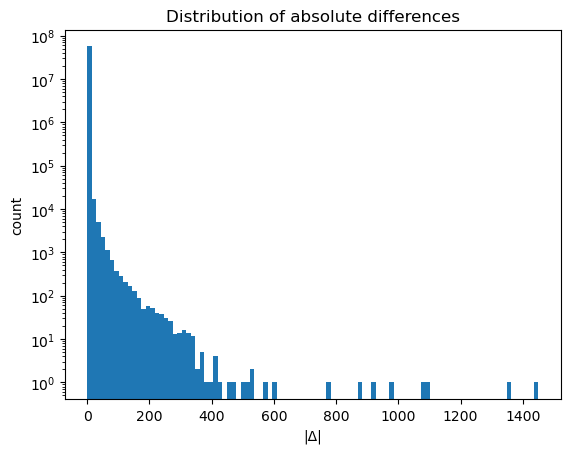

tensor([265269, 257229, 262813, 273303, 299417, 304086, 260557, 263686, 260867,
        261185, 252234, 234154], device='cuda:0')
{'tp': 3604055, 'fp': 846779, 'fn': 773256, 'precision': 0.8097482404421283, 'recall': 0.8233490834898411, 'f1': 0.8164920263543475, 'jaccard': 0.6898914452086392}
(array([261, 261, 261, 261, 261, 261, 261, 261, 261, 261, 261, 261,  79,
       261, 195, 195,  75, 195, 111, 261]), array([261, 261, 261, 261, 261, 261, 261, 261, 261, 261, 261, 261, 195,
       261,  79,  75, 195, 111, 195, 261]), array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 0, 3, 3, 3, 3, 3, 0]), array([ 0,  3,  8,  2,  7, 10,  1, 11,  9,  5,  0,  6,  4,  3,  4,  4,  4,
        4,  4,  2]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))


C:\Users\luiyu\AppData\Local\Temp\ipykernel_14764\794966711.py:57: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  print(np.unravel_index(idx.cpu(), diff.shape))


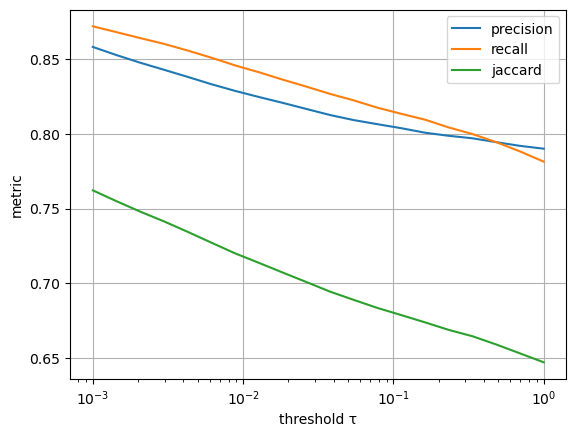

In [7]:
coords = (data != 0).nonzero(as_tuple=False)

BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model_nomask.G_DK_M]
BPTF_E_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model_nomask.E_DK_M]
data_hat_torch = BPTF_model_torch_nomask.reconstruct(style='geometric')
data_hat = tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M))
if use_existing_data:
    data_hat_torch = data_hat_torch[tuple(coords.T)]
    data_hat = data_hat[tuple(coords.T)]
    fro_norm_rel_diff = torch.norm(data_hat_torch - data_hat, 'fro') / torch.norm(data_hat, 'fro')
    print(f'Frobenius norm relative difference with only unmasked data: {fro_norm_rel_diff}')
else:
    fro_norm_rel_diff = torch.norm(data_hat_torch - data_hat, 'fro') / torch.norm(data_hat, 'fro')
    print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

print(f'correlation index for geom mean {tl.metrics.similarity.correlation_index(BPTF_G_DK_M, BPTF_model_torch_nomask.G_DK_M)}')
print(f'correlation index for arithmetic mean {tl.metrics.similarity.correlation_index(BPTF_E_DK_M, BPTF_model_torch_nomask.E_DK_M)}')

threshold = 0.05
diff = torch.abs(BPTF_model_torch_nomask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
prop_exceed = (diff > threshold).sum().item() / diff.numel()
print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

# BPTF
for m in range(len(BPTF_G_DK_M)):
    print(f'Fro norm of BPTF factors = {torch.norm(BPTF_G_DK_M[m])}')

# BPTF torch
for m in range(len(BPTF_G_DK_M)):
    print(f'Fro norm of BPTF_torch factors = {torch.norm(BPTF_model_torch_nomask.G_DK_M[m])}')

for m, (A_ref, A_torch) in enumerate(zip(BPTF_G_DK_M, BPTF_model_torch_nomask.G_DK_M)):
    print(f"mode {m}: ref mean={A_ref.mean():.3f}, std={A_ref.std():.3f}; "
          f"torch mean={A_torch.mean():.3f}, std={A_torch.std():.3f}")

# 1) How big are the large errors?
big = diff[diff > 0.05]
print(big.mean(), big.median(), big.max())

# 2) Histogram of the absolute differences
import matplotlib.pyplot as plt
plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')
plt.show()

# 3) Where do they occur?  Example for mode-4 time slices
exceed_mask = (diff > 0.05)
time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
print(time_exceed)  # counts per month

# Check whether the predictions for nnz locations are the same
nnz_prediction_stats = compare_support(BPTF_model_torch_nomask.reconstruct(style='geometric'), tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), thr=0.05)
print(nnz_prediction_stats)

diff = (BPTF_model_torch_nomask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M))).abs()
idx   = diff.flatten().topk(20).indices
print(np.unravel_index(idx.cpu(), diff.shape))

thrs = np.logspace(-3, 0, 20)          # 0.001 … 1
stats = [compare_support(BPTF_model_torch_nomask.reconstruct(style='geometric'), tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), thr=t) for t in thrs]

prec = [s['precision'] for s in stats]
rec  = [s['recall']    for s in stats]
jacc = [s['jaccard']   for s in stats]

plt.semilogx(thrs, prec, label='precision')
plt.semilogx(thrs, rec,  label='recall')
plt.semilogx(thrs, jacc, label='jaccard')
plt.xlabel('threshold τ'); plt.ylabel('metric'); plt.legend(); plt.grid(True)
plt.show()

In [8]:
from scipy.optimize import linear_sum_assignment

def match_components(factors_ref, factors_own):
    N = len(factors_ref)
    R = factors_ref[0].shape[1]
    # build per-mode absolute correlations
    S_modes = []
    for A, B in zip(factors_ref, factors_own):
        A_n = (A / A.norm(dim=0, keepdim=True))
        B_n = (B / B.norm(dim=0, keepdim=True))
        S_modes.append((A_n.T @ B_n).abs().cpu().numpy())
    S = sum(S_modes) / N     # average similarity matrix
    row_ind, col_ind = linear_sum_assignment(1 - S)
    return row_ind, col_ind

# reference and your torch factors
f_ref   = BPTF_G_DK_M
f_own   = BPTF_model_torch_nomask.G_DK_M

row_ind, col_ind = match_components(f_ref, f_own)
# build permuted list of your factors:
# Now permute the *columns* in each factor:
f_own_aligned = [
    B[:, col_ind]    # re-order columns by the matching col_ind
    for B in f_own
]

# Recompute reconstructions
Y_ref        = tl.cp_tensor.cp_to_tensor((None, f_ref))
Y_own_aligned = tl.cp_tensor.cp_to_tensor((None, f_own_aligned))

fro_rel = (Y_ref - Y_own_aligned).norm() / Y_ref.norm()
corr    = tl.metrics.similarity.correlation_index(f_ref, f_own_aligned)

print(f"Post-match rel. Fro error: {fro_rel:.4f}")
print(f"Post-match corr index: {corr:.4f}")

Post-match rel. Fro error: 0.2347
Post-match corr index: 0.1696


In [9]:
import pandas as pd

# Replace these with your actual objects
orig = BPTF_model_nomask        # Aaron’s reference
tch  = BPTF_model_torch_nomask  # Your PyTorch version
n_modes = len(orig.shp_DK_M)

rows = []
for m in range(n_modes):
    shp_ref, shp_tch = orig.shp_DK_M[m],       tch.shp_DK_M[m].cpu().numpy()
    rte_ref, rte_tch = orig.rte_DK_M[m],       tch.rte_DK_M[m].cpu().numpy()
    rows.append({
        "mode": m,
        "mean|Δshape|": np.abs(shp_ref - shp_tch).mean(),
        "max|Δshape|":  np.abs(shp_ref - shp_tch).max(),
        "mean|Δrate|":  np.abs(rte_ref - rte_tch).mean(),
        "max|Δrate|":   np.abs(rte_ref - rte_tch).max(),
    })

df = pd.DataFrame(rows).set_index("mode")
print(df)

       mean|Δshape|    max|Δshape|   mean|Δrate|     max|Δrate|
mode                                                           
0       4453.245678  421975.638028  74301.133854  127255.743304
1       4502.299297  401132.776251    921.737623    2002.949445
2      18851.120366  292654.238938  12550.015892   29167.061747
3      29758.412031  140129.461822  24156.052328   47597.318674
4     121364.224516  668424.366378  89306.260815  147200.362568


### plotting components (run only if using existing data)

In [12]:
from plot_utility_functions import plot_all_components
import pickle

with open('name_lists.pkl', 'rb') as f:
    name_lists = pickle.load(f)

actors, actions, dates, databases = name_lists
print(dates)

plot_all_components([fac.cpu().numpy() for fac in BPTF_G_DK_M],
                    actors['country'],
                    actions['action'],
                    dates['date'])

        date  index
0    2000-01      0
1    2000-02      1
2    2000-03      2
3    2000-04      3
4    2000-05      4
..       ...    ...
289  2024-02    289
290  2024-03    290
291  2024-04    291
292  2024-05    292
293  2024-06    293

[294 rows x 2 columns]
Plotting...


100%|██████████| 10/10 [00:14<00:00,  1.48s/it]

c:\Users\luiyu\Documents\aaron_schein\bptf_new\plots


from plot_utility_functions import plot_all_components


## With mask

In [11]:
# BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model_withmask.G_DK_M]
# fro_norm_rel_diff = torch.norm(BPTF_model_torch_withmask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
# print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

# threshold = 0.05
# diff = torch.abs(BPTF_model_torch_withmask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
# prop_exceed = (diff > threshold).sum().item() / diff.numel()
# print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

# # 1) How big are the large errors?
# big = diff[diff > 0.05]
# print(big.mean(), big.median(), big.max())

# # 2) Histogram of the absolute differences
# import matplotlib.pyplot as plt
# plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
# plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')

# # 3) Where do they occur?  Example for mode-4 time slices
# exceed_mask = (diff > 0.05)
# time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
# print(time_exceed)  # counts per month